# 1. deseason and detrend

In [25]:
#--deseason and detrend
def detrend_dim(da, dim, deg=1):
    p = da.polyfit(dim=dim, deg=deg)
    fit = xr.polyval(da[dim], p.polyfit_coefficients)
    return da - fit

def coarsen(da,scale):
    # da= da.rename({"lon": "longitude", "lat": "latitude"})
    da=da.coarsen(latitude=scale,longitude=scale).mean().sel(latitude=slice(79,-81))
    da['longitude'] =da['longitude'].where(da['longitude'] != -9999)
    da['latitude'] = da['latitude'].where(da['latitude'] != -9999)
    return da
    
def deseason(ds):
   
    var_mean = ds.groupby('time.month').mean(dim='time')
    var_anom=ds.groupby('time.month')-var_mean
    var_anom['longitude'] = var_anom['longitude'].where(var_anom['longitude'] != -9999)
    var_anom['latitude'] = var_anom['latitude'].where(var_anom['latitude'] != -9999)
    return var_anom

# 2. c3s data to anormalies

In [15]:
import xarray as xr
ds_list=[]
for year in range(2001,2019):
    for month in range(1,13):
        file='../cds/C3S-SOILMOISTURE-L3S-SSMV-COMBINED-MONTHLY-'+str(year)+str(month).zfill(2)+'01000000-TCDR-v202312.0.0.nc'
        ds=xr.open_dataset(file).sm
        ds_list.append(ds)

combined_ds = xr.concat(ds_list, dim="time")
combined_ds = combined_ds.sortby("time")
combined_ds.to_netcdf('/Net/Groups/BGI/scratch/fhuang/lac_uta_res/input_data2/sm_cds.nc')
combined_ds= combined_ds.rename({"lon": "longitude", "lat": "latitude"})
combined_ds2=coarsen(combined_ds,scale=6)
combined_ds2.to_netcdf('/Net/Groups/BGI/scratch/fhuang/lac_uta_res/input_data2/sm_cds_1d50.nc')
var_dt=detrend_dim(combined_ds2, dim='time', deg=1)
var_ab=deseason(var_dt)
var_ab.to_netcdf('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/cds.nc')

# 3. grace data to anormalies

In [76]:
import xarray as xr
ds_list=[]
file_list=os.listdir('../lac_cnn2/GRACE_NC4_Files/')
for file_name in file_list:
    ds=xr.open_dataset('../lac_cnn2/GRACE_NC4_Files/'+file_name).sfsm_inst                
    ds_list.append(ds)

combined_ds = xr.concat(ds_list, dim="time")
combined_ds = combined_ds.sortby("time")
combined_ds.to_netcdf('/Net/Groups/BGI/scratch/fhuang/lac_uta_res/input_data2/sm_grace.nc')
combined_ds= combined_ds.rename({"lon": "longitude", "lat": "latitude"})

In [128]:
da=combined_ds
scale=6
da=da.coarsen(latitude=scale,longitude=scale).mean()
combined_ds2= da.resample(time="M").mean()[0:-76]
# combined_ds2.to_netcdf('/Net/Groups/BGI/scratch/fhuang/lac_uta_res/input_data2/sm_grace_1d50.nc')
var_dt=detrend_dim(combined_ds2, dim='time', deg=1)
var_ab=deseason(var_dt)
var_ab.to_netcdf('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/grace3.nc')

/Net/Groups/BGI/scratch/fhuang/.conda/envs/hfng/lib/python3.10/site-packages/xarray/core/groupby.py:508: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


# 4. comparison anormalies from 6 data sources

In [183]:
import xarray as xr
import numpy as np
somo=xr.open_dataarray('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/somo.nc').transpose("latitude", "longitude", "time")[:,:,25:]
gleam=xr.open_dataarray('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/gleam.nc').transpose("latitude", "longitude", "time")[:,:,25:]
esa=xr.open_dataarray('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/esa.nc').transpose("latitude", "longitude", "time")[:,:,25:]
era5=xr.open_dataarray('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/era5.nc').transpose("latitude", "longitude", "time")[:,:,25:]
cds=xr.open_dataarray('/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/input_data/deseason_detrend/cds.nc').transpose("latitude", "longitude", "time")[:,:,25:]
grace=xr.open_dataarray('/Net/Groups/BGI/scratch/fhuang/lac_uta_res/input_data2/sm_grace_1d50.nc').transpose("latitude", "longitude", "time")
grace = grace.sel(latitude=slice(None, None, -1))

# 5. interpolate to 2cm (as GRACE)

In [22]:
# Linear interpolation to 2cm depth
def interpolate_to_target(depth_values, moisture_values, target_depth=2):
    """Interpolate soil moisture to target depth"""
    interp_func = interpolate.interp1d(
        depth_values, 
        moisture_values,
        kind='linear',
        bounds_error=False,
        fill_value='extrapolate'
    )
    return interp_func(target_depth)

In [23]:
somo=interpolate_to_target(10, somo, target_depth=2)
gleam=interpolate_to_target(7, gleam, target_depth=2)
esa=interpolate_to_target(7, esa, target_depth=2)
cds=interpolate_to_target(7, cds, target_depth=2)
era5=interpolate_to_target(7, era5, target_depth=2)

# 6. plots

somo somo
somo gleam
somo era5
somo esa
somo cds
somo grace
gleam somo
gleam gleam
gleam era5
gleam esa
gleam cds
gleam grace
era5 somo
era5 gleam
era5 era5
era5 esa
era5 cds
era5 grace
esa somo
esa gleam
esa era5
esa esa
esa cds
esa grace
cds somo
cds gleam
cds era5
cds esa
cds cds
cds grace
grace somo
grace gleam
grace era5
grace esa
grace cds
grace grace


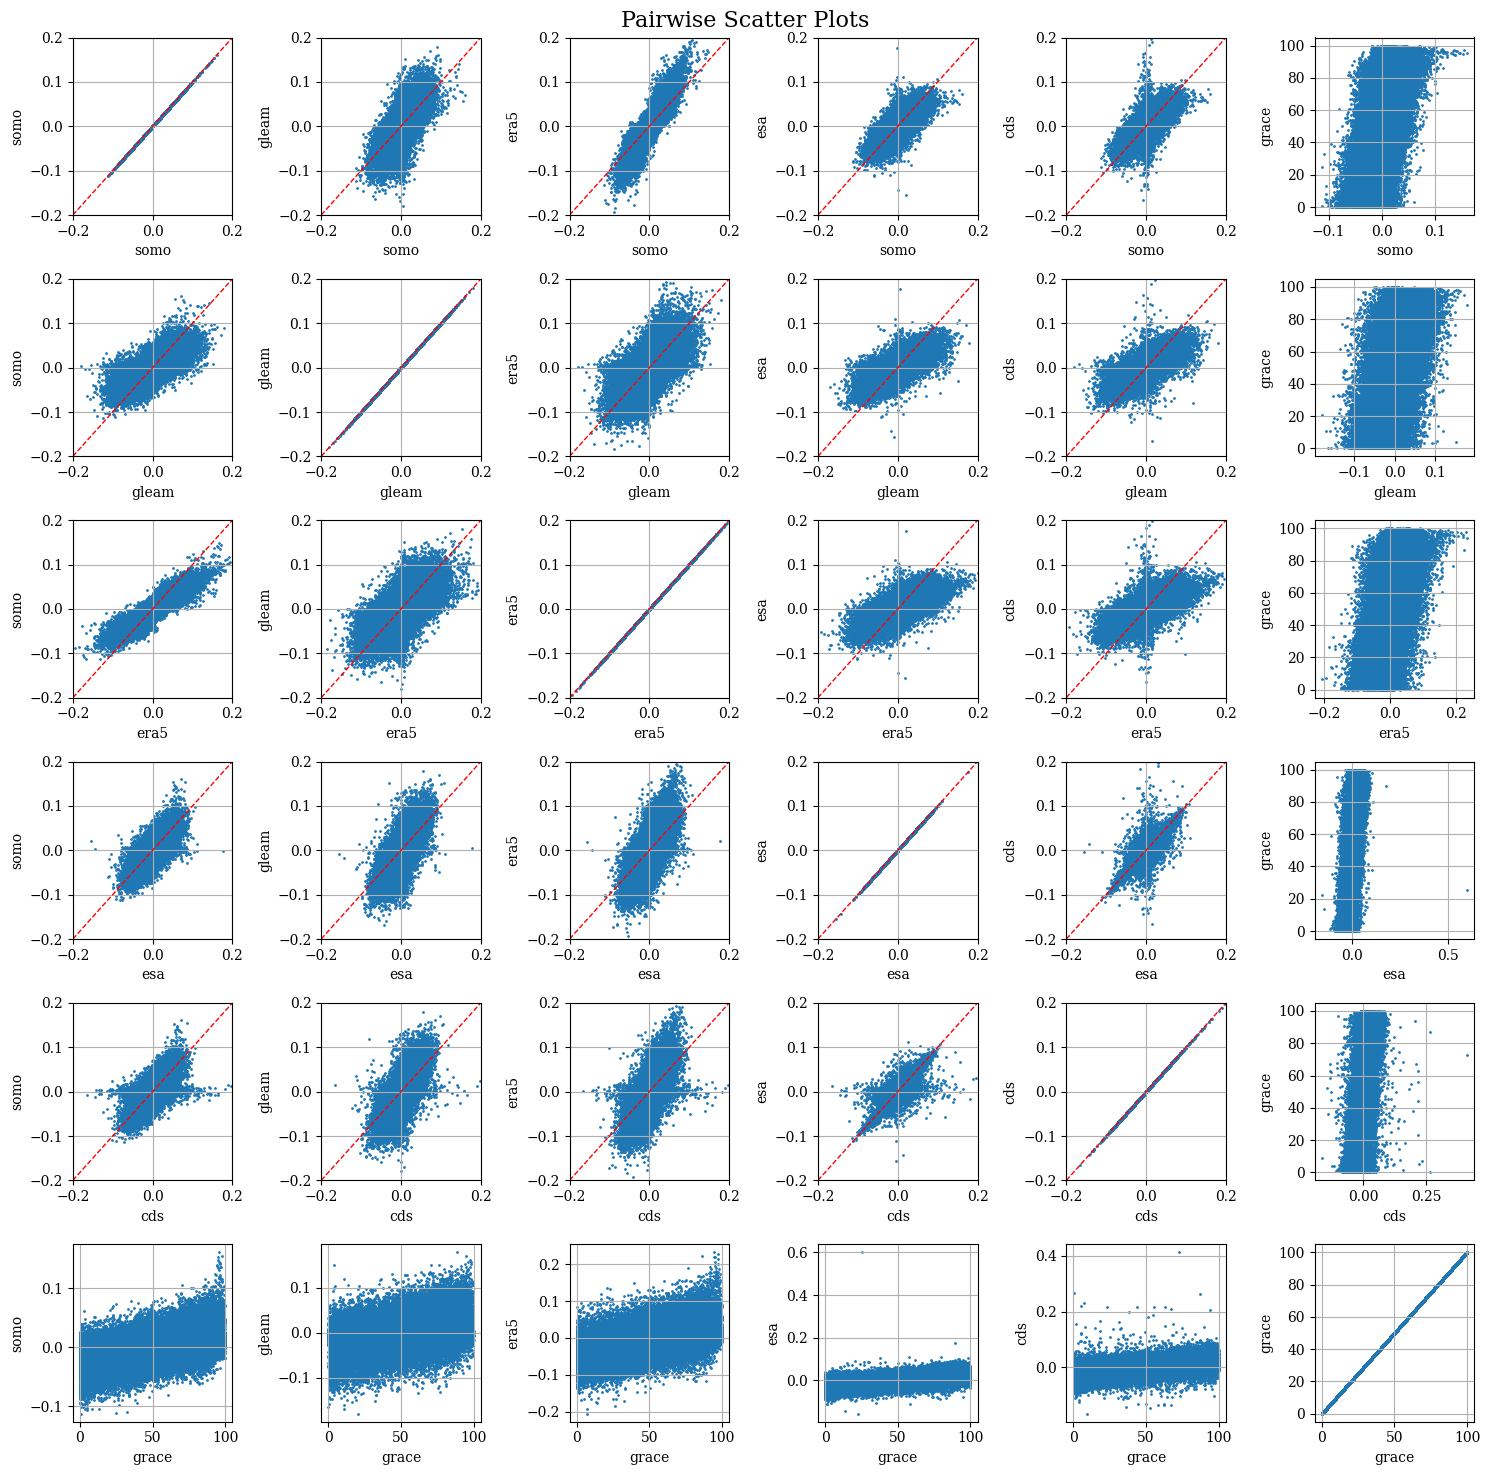

In [185]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
data = {
    'somo': somo.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1),
    'gleam': gleam.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1),
    'era5': era5.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1),
    'esa': esa.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1),
    'cds': cds.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1),
    'grace': grace.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)
}

# Create subplots
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(15, 15))
fig.suptitle('Pairwise Scatter Plots', fontsize=16)

# Remove redundant plots (diagonal and upper triangle)
for i in range(6):
    for j in range(6):
        x_var = list(data.keys())[i]
        y_var = list(data.keys())[j]
        print(x_var,y_var)
        axes[i, j].scatter(data[x_var], data[y_var], s=1)
        axes[i, j].set_xlabel(x_var)
        axes[i, j].set_ylabel(y_var)
        axes[i, j].grid(True)
        
        if (i <5) and (j<5):
            axes[i, j].plot([-0.2, 0.2], [-0.2, 0.2],color='red', linestyle='--', linewidth=1,)
            axes[i,j].set_xlim(-0.2,0.2)
            axes[i,j].set_ylim(-0.2,0.2)
plt.tight_layout()
plt.show()

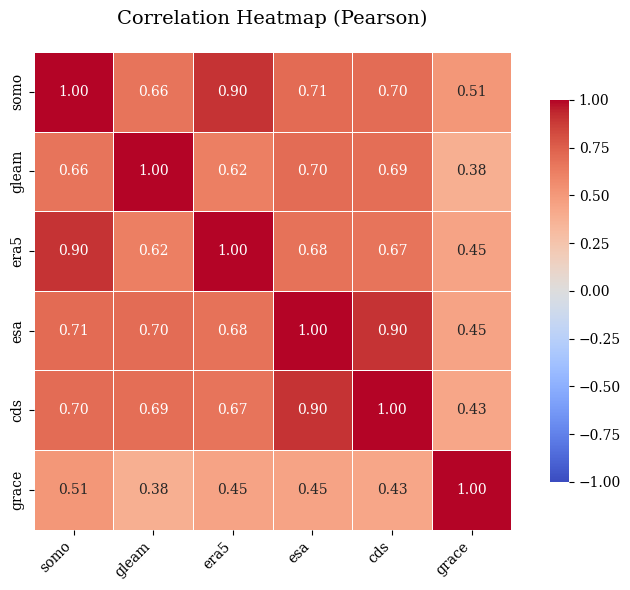

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'somo': somo.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)[:,0],
    'gleam': gleam.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)[:,0],
    'era5': era5.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)[:,0],
    'esa': esa.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)[:,0],
    'cds': cds.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)[:,0],
    'grace': grace.sel(latitude=slice(15,-60),longitude=slice(-85,-30)).values.reshape(-1,1)[:,0]
}


df = pd.DataFrame(data)
corr_matrix = df.corr()


plt.figure(figsize=(8, 6))

# Plot heatmap with annotations
sns.heatmap(
    corr_matrix,
    annot=True,          # Show numbers in cells
    fmt=".2f",          # Format: 2 decimal places
    cmap="coolwarm",    # Color map (red for +ve, blue for -ve)
    vmin=-1, vmax=1,    # Fix color scale to [-1, 1]
    linewidths=0.5,     # Add grid lines
    square=True,        # Ensure square cells
    cbar_kws={"shrink": 0.8}  # Adjust color bar size
)

# Customize labels
plt.title("Correlation Heatmap (Pearson)", pad=20, fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.tight_layout()  # Prevent label cutoff
plt.show()